In [1]:
from pyRTC.Loop import *
from pyRTC.Pipeline import *
from pyRTC.utils import *
import numpy as np
import matplotlib.pyplot as plt
import torch
from pyRTC.hardware.models import *

torch.set_grad_enabled(False)

In [3]:
device = "cuda:0"
modelDType = np.float32
tensorType = torch.float32
use_next_pol = True
normMethod = 1
burnCount = 4999

data_in = np.load(f"debugdata/j12moving_predict_debug_info_{burnCount}.npz")

halfPrecision = False

# currentCorrection=currentCorrection.detach().cpu().numpy(), 
# slopes=slopes.detach().cpu().numpy(), 
# next_pol=next_pol.detach().cpu().numpy(),
# self_pol=pol.detach().cpu().numpy(),
# norm_mean=norm_mean.detach().cpu().numpy(), 
# norm_std=norm_std.detach().cpu().numpy(), 
# model_in=modelIn.read_noblock_safe(),
# model_out=modelOut.read_noblock_safe(),
# #modelIn=modelIn.detach().cpu().numpy(), 
# net_output=raw_output.detach().cpu().numpy(), 
# newCorrection=newCorrection)

pol = data_in["self_pol"]
norm_mean = data_in["norm_mean"]
norm_std = data_in["norm_std"]
next_pol = data_in["next_pol"]

In [35]:
def loadModel(pathToModel):
    
    nb = 4
    nf = 64
    model = DenseNet(block_num=nb, num_features=nf)
    model.load_state_dict(torch.load(f'/home/whetstone/Downloads/torch/torch/logs/{pathToModel}/netG_epoch_74.pth'))

    model = model.to(device).eval()
    x = torch.randn(1, 20, 48, 24, device=device)

    if halfPrecision:
        model = model.half().eval()
        x = x.half()

    cudaGraph = torch.compile(model, mode='max-autotune-no-cudagraphs').eval() #, mode='max-autotune')
    output = cudaGraph(x)

    print(f'Model Loaded {output.shape}')

    return cudaGraph, x

cudaGraph, x = loadModel('shlong_10_1step0m')

Model Loaded torch.Size([1, 1, 48, 24])


In [36]:
nm = pol[:,-1,...].mean()
ns = pol[:,-1,...].std()

#Data to send to network
modelInput = (pol-nm)/ns

#Send to network
raw_output = cudaGraph(torch.from_numpy(modelInput).to(device).type(tensorType))

#fix output and send to shm for debug
net_output = raw_output.detach().cpu().numpy()
net_output = (net_output*ns) + nm
# net_output[:, :, 24:, :] *= -1

# newCorrection = newCorrection.detach().cpu().numpy().astype(modelDType)
# pol[:, -1, ...] = net_output.reshape(1, 1, 48, 24).type(tensorType)


2024-05-28 22:41:38,883 matplotlib.colorbar [DEBUG] - locator: <matplotlib.ticker.AutoLocator object at 0x7f154a346d90>
2024-05-28 22:41:38,900 matplotlib.colorbar [DEBUG] - locator: <matplotlib.ticker.AutoLocator object at 0x7f15984c50d0>
2024-05-28 22:41:38,918 matplotlib.colorbar [DEBUG] - locator: <matplotlib.ticker.AutoLocator object at 0x7f15985a7b10>


2024-05-28 22:41:38,935 matplotlib.colorbar [DEBUG] - locator: <matplotlib.ticker.AutoLocator object at 0x7f154a329790>
2024-05-28 22:41:38,952 matplotlib.colorbar [DEBUG] - locator: <matplotlib.ticker.AutoLocator object at 0x7f154a2a5d10>
2024-05-28 22:41:38,965 matplotlib.colorbar [DEBUG] - locator: <matplotlib.ticker.AutoLocator object at 0x7f159859ba50>


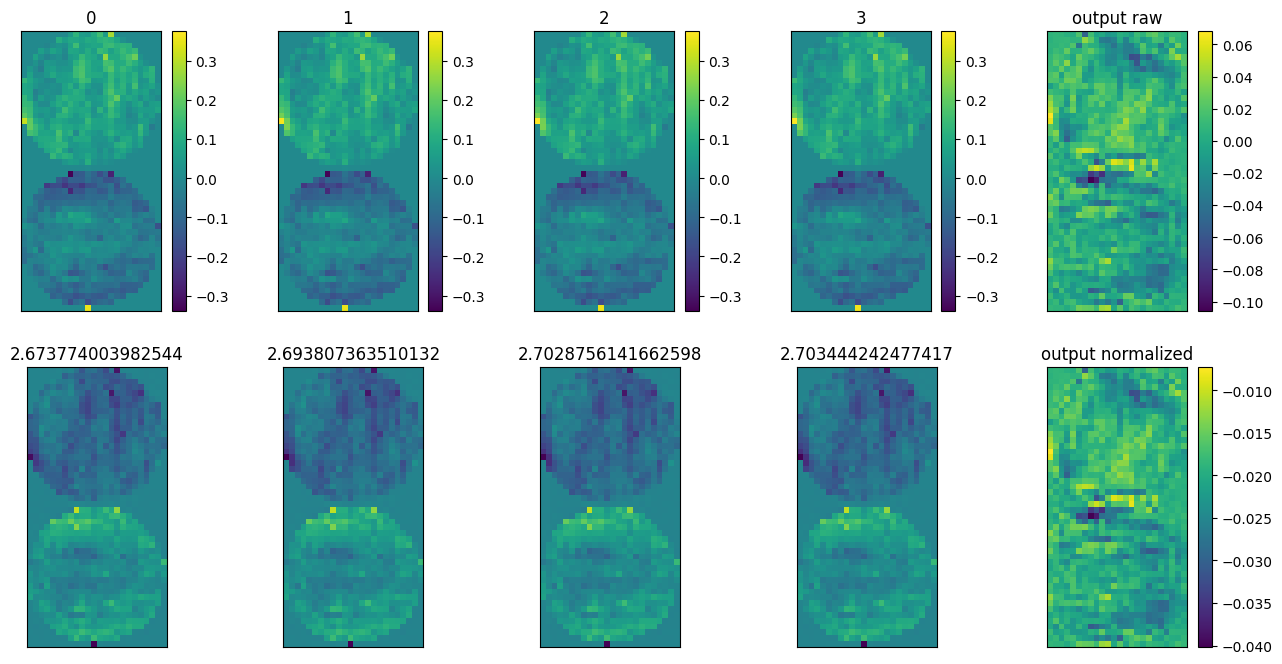

In [37]:
plt.figure(figsize=(16,8))

mout = -2.5*net_output.squeeze()
rout = raw_output.squeeze().detach().cpu().numpy()
rout[:,:] *= -1


pmin = pol.min()
pmax = pol.max()

for jj in range(4):
    plt.subplot(2,5,1+jj)
    plt.imshow(pol[:, -4+jj, :, :].reshape(48, 24), vmin=pmin, vmax=pmax)
    plt.title(f'{jj}')
    plt.xticks([])
    plt.yticks([])
    plt.colorbar()

    plt.subplot(2,5,6+jj)
    plt.imshow(mout-pol[:, -4+jj, :, :].reshape(48, 24), vmin=pmin, vmax=pmax)
    plt.title(f'{np.linalg.norm(mout-pol[:, -4+jj, :, :].reshape(48, 24))}')
    plt.xticks([])
    plt.yticks([])
    #plt.colorbar()

plt.subplot(2,5,10)
plt.imshow(mout) #, vmin=pmin, vmax=pmax)
plt.colorbar()
plt.title(f'output normalized')
plt.xticks([])
plt.yticks([])

plt.subplot(2,5,5)
plt.imshow(rout - rout.mean()) #, vmin=pmin, vmax=pmax)
plt.colorbar()
plt.title(f'output raw')
plt.xticks([])
plt.yticks([])

plt.show()


In [38]:
print(pol.mean(), pol.std())
print(norm_mean, norm_std)

0.00745933 0.07474653
0.007459331 0.07474814
